# ✈️ L'effet domino des retards — Vols au départ d'Atlanta, été 2022

**Projet final — Module Visualisation des Données**

## 1. Introduction

Un vol en retard n'est pas seulement un problème pour ses passagers : l'avion est attendu ailleurs,
et son retard peut se reporter sur les vols suivants. Ce projet étudie **quand, où et pourquoi**
les vols prennent du retard, à partir de données officielles réelles.

**Phrase résumé :** *un retard de vol ne naît pas au hasard : il grandit au fil de la journée.
Nous l'avons mesuré sur 54 000 vols au départ du premier aéroport du monde.*

**Plan du notebook :** dataset → problématique → exploration → qualité → nettoyage →
échantillonnage → analyses univariée, bivariée, multivariée → insights → conclusion.

## 2. Présentation du dataset

| Élément | Détail |
|---|---|
| Source | Kaggle — [*Flight Status Prediction*](https://www.kaggle.com/datasets/robikscube/flight-delay-dataset-20182022) (auteur : robikscube) |
| Origine des données | Bureau of Transportation Statistics (BTS), organisme officiel des transports des États-Unis |
| Fichier utilisé | `Combined_Flights_2022.parquet` : 4 078 318 vols, janvier à juillet 2022 |
| **Périmètre d'étude** | **Tous les vols au départ d'Atlanta (ATL), juin et juillet 2022** |
| Taille du périmètre | **54 461 vols × 61 colonnes** |

**Pourquoi ce périmètre ?**
- **Atlanta** est l'aéroport le plus fréquenté du monde : beaucoup de vols, de compagnies et de destinations.
- **Juin–juillet** est le pic des retards de l'année (≈ 26 % de vols en retard, contre ≈ 15 % en janvier-février).
- Un seul aéroport permet de suivre **les mêmes avions** qui partent plusieurs fois par jour : c'est ce qui rend
  l'étude de l'effet domino possible.
- 54 461 lignes : au-dessus du minimum demandé (30 000), et assez léger pour travailler facilement.

**Lien avec le monde professionnel :** la ponctualité est l'indicateur central de tout exploitant de transport
(aérien, bus, train). Le même raisonnement s'applique à un réseau de bus : un retard sur un premier service
se reporte sur les services suivants du même véhicule.

## 3. Problématique

> **Quand et pourquoi les vols au départ d'Atlanta prennent-ils du retard pendant l'été 2022 ?**

| # | Sous-question | Variables utilisées |
|---|---|---|
| 1 | Quelle est l'ampleur des retards ? | `DepDelay`, `DepDel15`, `Cancelled` |
| 2 | Comment le retard évolue-t-il au fil de la journée et de la semaine ? | `CRSDepTime`, `DayOfWeek`, `FlightDate` |
| 3 | Quelles compagnies et quelles destinations sont les plus touchées ? | `Airline`, `Dest`, `Distance` |
| 4 | Le retard au départ se rattrape-t-il en vol ? | `DepDelay`, `ArrDelay` |
| 5 | Un retard se transmet-il d'un vol à l'autre du même avion (effet domino) ? | `Tail_Number`, `DepDel15` |

**Définition utilisée :** un vol est « en retard » s'il part **plus de 15 minutes** après l'heure prévue
(définition officielle du BTS, colonne `DepDel15`).

## 4. Chargement des données

Le code est rangé dans le dossier `src/` (un fichier par étape). Le notebook appelle ces fonctions
pour rester court et lisible.

L'extraction du périmètre (4 millions de vols → 54 461 vols) a été faite une seule fois avec
`python src/data_loading.py`. Ici, on charge directement le fichier extrait.

In [1]:
import sys
sys.path.append("../src")

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns

from data_loading import charger_vols_atlanta
from preprocessing import nettoyer_vols, colonnes_constantes, FICHIER_PROPRE
from sampling import METHODES, comparer_echantillons, stabilite_des_methodes, echantillon_stratifie_par_jour
from analysis import (resume_qualite, vols_partis, taux_de_retard_par, effet_domino,
                      tableau_croise_retard, VARIABLES_NUMERIQUES_CLES)
from visualizations import (appliquer_style, barres_horizontales, ligne_temporelle, format_pourcentage,
                            enregistrer_figure, BLEU, ORANGE, VERT_EAU, GRIS, ENCRE_SECONDAIRE, PLOTLY_LAYOUT)

appliquer_style()
pd.set_option("display.max_columns", 70)

vols_bruts = charger_vols_atlanta()
vols_bruts.shape

(54461, 61)

## 5. Exploration

### 5.1 Aperçu des premières lignes

In [2]:
vols_bruts.head()

,FlightDate,Airline,Origin,Dest,Cancelled,Diverted,CRSDepTime,DepTime,DepDelayMinutes,DepDelay,ArrTime,ArrDelayMinutes,AirTime,CRSElapsedTime,ActualElapsedTime,Distance,Year,Quarter,Month,DayofMonth,DayOfWeek,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,Flight_Number_Marketing_Airline,Operating_Airline,DOT_ID_Operating_Airline,IATA_Code_Operating_Airline,Tail_Number,Flight_Number_Operating_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,DestCityName,DestState,DestStateFips,DestStateName,DestWac,DepDel15,DepartureDelayGroups,DepTimeBlk,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,DistanceGroup,DivAirportLandings
0,2022-07-02,Comair Inc.,ATL,DCA,False,False,1006,959.0,0.0,-7.0,1154.0,0.0,85.0,113.0,115.0,547.0,2022,3,7,2,6,AA,AA_CODESHARE,19805,AA,5427,OH,20397,OH,N526EA,5427,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,11278,1127805,30852,"Washington, DC",VA,51,Virginia,38,0.0,-1.0,1000-1059,26.0,1025.0,1150.0,4.0,1159,-5.0,0.0,-1.0,1100-1159,3,0
1,2022-07-03,Comair Inc.,ATL,DCA,False,False,1106,1144.0,38.0,38.0,1320.0,20.0,80.0,114.0,96.0,547.0,2022,3,7,3,7,AA,AA_CODESHARE,19805,AA,5427,OH,20397,OH,N572NN,5427,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,11278,1127805,30852,"Washington, DC",VA,51,Virginia,38,1.0,2.0,1100-1159,13.0,1157.0,1317.0,3.0,1300,20.0,1.0,1.0,1300-1359,3,0
2,2022-07-09,Comair Inc.,ATL,DCA,False,False,1006,1119.0,73.0,73.0,1328.0,89.0,78.0,113.0,129.0,547.0,2022,3,7,9,6,AA,AA_CODESHARE,19805,AA,5427,OH,20397,OH,N514AE,5427,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,11278,1127805,30852,"Washington, DC",VA,51,Virginia,38,1.0,4.0,1000-1059,48.0,1207.0,1325.0,3.0,1159,89.0,1.0,5.0,1100-1159,3,0
3,2022-07-10,Comair Inc.,ATL,DCA,False,False,1106,1104.0,0.0,-2.0,1240.0,0.0,78.0,114.0,96.0,547.0,2022,3,7,10,7,AA,AA_CODESHARE,19805,AA,5427,OH,20397,OH,N590NN,5427,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,11278,1127805,30852,"Washington, DC",VA,51,Virginia,38,0.0,-1.0,1100-1159,14.0,1118.0,1236.0,4.0,1300,-20.0,0.0,-2.0,1300-1359,3,0
4,2022-07-16,Comair Inc.,ATL,DCA,False,False,1006,1104.0,58.0,58.0,1307.0,68.0,84.0,113.0,123.0,547.0,2022,3,7,16,6,AA,AA_CODESHARE,19805,AA,5427,OH,20397,OH,N522AE,5427,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,11278,1127805,30852,"Washington, DC",VA,51,Virginia,38,1.0,3.0,1000-1059,27.0,1131.0,1255.0,12.0,1159,68.0,1.0,4.0,1100-1159,3,0


### 5.2 Types des variables

In [3]:
vols_bruts.dtypes.value_counts()

int64             23
float64           18
object            17
bool               2
datetime64[ns]     1
Name: count, dtype: int64

Les 61 colonnes se répartissent en quatre familles :
- **numériques** : retards (minutes), temps de roulage (`TaxiOut`, `TaxiIn`), durée de vol (`AirTime`), distance…
- **catégorielles** : compagnie (`Airline`), destination (`Dest`), tranche horaire (`DepTimeBlk`), immatriculation de l'avion (`Tail_Number`)…
- **vrai/faux** : `Cancelled` (annulé), `Diverted` (dévié vers un autre aéroport) ;
- **temporelle** : `FlightDate`.

Le dictionnaire complet des variables est dans `docs/DATASET.md`.

### 5.3 Statistiques descriptives des variables numériques clés

In [4]:
vols_bruts[VARIABLES_NUMERIQUES_CLES].describe().round(1)

,DepDelay,ArrDelay,TaxiOut,TaxiIn,Distance,AirTime
count,53465.0,53329.0,53452.0,53448.0,54461.0,53329.0
mean,16.0,10.1,15.9,6.8,668.2,93.9
std,51.8,53.2,7.1,5.8,498.1,59.3
min,-21.0,-50.0,1.0,1.0,83.0,17.0
25%,-3.0,-12.0,12.0,4.0,356.0,56.0
50%,0.0,-4.0,14.0,5.0,563.0,82.0
75%,16.0,14.0,18.0,8.0,760.0,105.0
max,2493.0,2473.0,143.0,131.0,4502.0,560.0


**Lecture :**
- `DepDelay` (retard au départ, en minutes) : la **médiane est 0** mais la **moyenne est 16 min**.
  La moitié des vols part à l'heure ou en avance, mais quelques très gros retards (jusqu'à 2 493 min, soit 41 h)
  tirent la moyenne vers le haut. → On utilisera surtout la **médiane** et le **% de vols en retard**, moins sensibles aux extrêmes.
- Un `DepDelay` négatif veut dire que l'avion est parti **en avance**.
- `Distance` : de 83 à 4 502 miles ; la plupart des vols sont des vols courts (médiane 563 miles).

### 5.4 Cardinalité des variables catégorielles (nombre de valeurs différentes)

In [5]:
colonnes_texte = vols_bruts.select_dtypes(include="object").columns
vols_bruts[colonnes_texte].nunique().sort_values()

Origin                                        1
OriginStateName                               1
OriginState                                   1
OriginCityName                                1
Marketing_Airline_Network                     8
IATA_Code_Marketing_Airline                   8
Operated_or_Branded_Code_Share_Partners      11
Airline                                      14
Operating_Airline                            14
IATA_Code_Operating_Airline                  14
ArrTimeBlk                                   19
DepTimeBlk                                   19
DestState                                    49
DestStateName                                49
DestCityName                                143
Dest                                        147
Tail_Number                                3297
dtype: int64

**Lecture :** 14 compagnies, 147 destinations, 3 297 avions différents. Certaines colonnes n'ont
**qu'une seule valeur** (ex. `OriginCityName` = « Atlanta, GA ») : c'est normal puisqu'on n'a gardé
que les départs d'Atlanta. Elles seront retirées au nettoyage.

## 6. Qualité des données

### 6.1 Résumé

In [6]:
resume_qualite(vols_bruts).to_frame()

,Résultat
Nombre de lignes,54461.00
Nombre de colonnes,61.00
Variables numériques,41.00
Variables catégorielles (texte),17.00
Variables vrai/faux,2.00
Variables temporelles (dates),1.00
Colonnes avec valeurs manquantes,17.00
Cellules manquantes (%),0.51
Lignes en double,0.00


### 6.2 Valeurs manquantes

In [7]:
manquants = vols_bruts.isna().sum()
manquants = manquants[manquants > 0].sort_values(ascending=False)
pd.DataFrame({"nb manquants": manquants, "% des vols": (manquants / len(vols_bruts) * 100).round(2)})

,nb manquants,% des vols
ArrivalDelayGroups,1132,2.08
ArrDel15,1132,2.08
ArrDelayMinutes,1132,2.08
AirTime,1132,2.08
ActualElapsedTime,1132,2.08
ArrDelay,1132,2.08
ArrTime,1013,1.86
TaxiIn,1013,1.86
WheelsOn,1013,1.86
WheelsOff,1009,1.85


In [8]:
# Les valeurs manquantes correspondent-elles aux vols annulés ou déviés ?
print("Vols annulés :", vols_bruts["Cancelled"].sum())
print("Vols déviés  :", vols_bruts["Diverted"].sum())
print("Vols NON annulés sans heure de départ :", (~vols_bruts["Cancelled"] & vols_bruts["DepTime"].isna()).sum())
print("Vols sans immatriculation qui sont annulés :", vols_bruts.loc[vols_bruts["Tail_Number"].isna(), "Cancelled"].all())

Vols annulés : 1009
Vols déviés  : 123
Vols NON annulés sans heure de départ : 0
Vols sans immatriculation qui sont annulés : True


**Conclusion :** les valeurs manquantes ne sont **pas des erreurs**.
- ~1 000 vols **annulés** n'ont pas d'heure de départ ni de retard : ils n'ont jamais décollé.
- 123 vols **déviés** n'ont pas de retard à l'arrivée : ils ont atterri ailleurs.
- 75 vols annulés n'ont pas d'immatriculation d'avion (aucun avion n'avait été affecté).

→ **Décision : on ne remplit pas ces valeurs** (inventer un retard pour un vol annulé n'aurait pas de sens)
et on garde ces vols, car l'annulation fait partie du phénomène étudié.

### 6.3 Doublons

In [9]:
print('Lignes en double :', vols_bruts.duplicated().sum())

Lignes en double : 0


### 6.4 Valeurs aberrantes (outliers) du retard

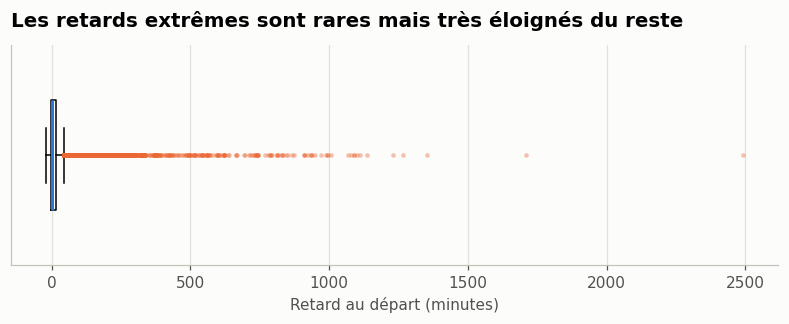

Q1 = -3 min, Q3 = 16 min, limite haute (Q3 + 1,5×IQR) = 44.5 min
Vols au-dessus de la limite : 11.6 %  |  vols avec plus de 3 h de retard : 631


In [10]:
fig, axe = plt.subplots(figsize=(9, 2.6))
axe.boxplot(vols_bruts["DepDelay"].dropna(), vert=False, widths=0.5,
            flierprops=dict(marker="o", markersize=3, markerfacecolor=ORANGE, markeredgecolor="none", alpha=0.4),
            medianprops=dict(color=BLEU, linewidth=2))
axe.set_yticks([])
axe.set_title("Les retards extrêmes sont rares mais très éloignés du reste")
axe.set_xlabel("Retard au départ (minutes)")
axe.grid(axis="x", visible=True); axe.grid(axis="y", visible=False)
plt.show()

q1, q3 = vols_bruts["DepDelay"].quantile([0.25, 0.75])
limite_haute = q3 + 1.5 * (q3 - q1)
part_outliers = (vols_bruts["DepDelay"] > limite_haute).mean() * 100
print(f"Q1 = {q1:.0f} min, Q3 = {q3:.0f} min, limite haute (Q3 + 1,5×IQR) = {limite_haute:.1f} min")
print(f"Vols au-dessus de la limite : {part_outliers:.1f} %  |  vols avec plus de 3 h de retard : {(vols_bruts['DepDelay'] > 180).sum()}")

**Lecture :** selon la règle de l'IQR, environ 12 % des vols seraient des « outliers » (retard > 44,5 min).
Mais ce ne sont **pas des erreurs de saisie** : ce sont de vrais vols très en retard, et c'est justement
le phénomène qu'on étudie.

→ **Décision : on garde les retards extrêmes.** Pour que les graphiques restent lisibles,
on limitera l'axe (ex. histogramme de −30 à 180 min) et on utilisera des indicateurs robustes
(médiane, % de vols en retard).

### 6.5 Incohérences

In [11]:
print("Vols annulés mais avec une heure de départ :", (vols_bruts["Cancelled"] & vols_bruts["DepTime"].notna()).sum())
print("Vols déviés avec un retard à l'arrivée     :", (vols_bruts["Diverted"] & vols_bruts["ArrDelay"].notna()).sum())

Vols annulés mais avec une heure de départ : 13
Vols déviés avec un retard à l'arrivée     : 0


**Lecture :** 13 vols sont annulés alors qu'ils ont une heure de départ. Ce n'est pas forcément une erreur :
l'avion a pu quitter la porte d'embarquement puis le vol a été annulé avant le décollage. Ces 13 vols (0,02 %)
sont gardés et comptés comme annulés.

| Élément | Résultat |
|---|---|
| Nombre de lignes | 54 461 |
| Nombre de colonnes | 61 |
| Variables numériques | 41 |
| Variables catégorielles | 17 |
| Variables vrai/faux | 2 |
| Variables temporelles | 1 (`FlightDate`) |
| Valeurs manquantes | 17 colonnes, liées aux vols annulés/déviés (≈ 2 %) |
| Doublons | 0 |
| Outliers | ≈ 12 % selon l'IQR, gardés (vrais retards) |

## 7. Nettoyage

Toutes les étapes sont dans `src/preprocessing.py` (fonction `nettoyer_vols`). Le fichier brut n'est
**jamais modifié** : on crée une copie nettoyée dans `data/processed/`.

| Étape | Décision | Pourquoi |
|---|---|---|
| Colonnes constantes | 10 colonnes supprimées | Une seule valeur (ex. ville de départ = Atlanta) : aucune information |
| Doublons | Aucun à supprimer | Vérifié |
| Valeurs manquantes | Gardées telles quelles | Elles correspondent aux vols annulés / déviés |
| Outliers | Gardés | Ce sont de vrais retards |
| Nouvelles colonnes | 8 colonnes ajoutées | Rendre l'analyse lisible et répondre aux sous-questions |

In [12]:
print("Colonnes constantes supprimées :", colonnes_constantes(vols_bruts))
vols = nettoyer_vols(vols_bruts)
vols.to_csv(FICHIER_PROPRE, index=False)
print("Avant :", vols_bruts.shape, "→ Après :", vols.shape)

Colonnes constantes supprimées : ['Origin', 'Year', 'OriginAirportID', 'OriginAirportSeqID', 'OriginCityMarketID', 'OriginCityName', 'OriginState', 'OriginStateFips', 'OriginStateName', 'OriginWac']


Avant : (54461, 61) → Après : (54461, 59)


**Colonnes ajoutées :**

| Colonne | Contenu |
|---|---|
| `heure_depart_prevue` | heure prévue de départ (0 à 23), tirée de `CRSDepTime` (ex. 1435 → 14) |
| `jour_semaine`, `mois` | noms en français (Lundi…, Juin/Juillet) |
| `compagnie` | nom court ; les compagnies avec moins de 1 000 vols sont regroupées en « Autres » (trop peu de vols pour comparer) |
| `statut` | À l'heure / En retard / Annulé / Dévié |
| `minutes_rattrapees` | retard au départ − retard à l'arrivée : minutes regagnées pendant le vol |
| `rang_rotation` | 1er, 2e, 3e… départ de la journée du même avion depuis Atlanta |
| `vol_precedent_en_retard` | le départ précédent du même avion (même jour) était-il en retard ? (1 = oui, 0 = non) |

In [13]:
vols[['FlightDate', 'compagnie', 'Dest', 'heure_depart_prevue', 'statut', 'DepDelay', 'Tail_Number', 'rang_rotation', 'vol_precedent_en_retard']].head(8)

,FlightDate,compagnie,Dest,heure_depart_prevue,statut,DepDelay,Tail_Number,rang_rotation,vol_precedent_en_retard
0,2022-07-02,Autres,DCA,10,À l'heure,-7.0,N526EA,1.0,NaN
1,2022-07-03,Autres,DCA,11,En retard,38.0,N572NN,1.0,NaN
2,2022-07-09,Autres,DCA,10,En retard,73.0,N514AE,1.0,NaN
3,2022-07-10,Autres,DCA,11,À l'heure,-2.0,N590NN,1.0,NaN
4,2022-07-16,Autres,DCA,10,En retard,58.0,N522AE,1.0,NaN
5,2022-07-17,Autres,DCA,11,À l'heure,-11.0,N570NN,1.0,NaN
6,2022-07-23,Autres,DCA,10,À l'heure,-9.0,N515AE,1.0,NaN
7,2022-07-24,Autres,DCA,11,À l'heure,-8.0,N604NN,1.0,NaN


## 8. Échantillonnage

**Population** = les 54 461 vols. **Taille visée** = 5 000 vols (≈ 10 %).

**Pourquoi échantillonner ?** Les nuages de points avec 54 000 points deviennent une tache illisible,
et ils sont lents à afficher dans le dashboard. Un échantillon **représentatif** de 5 000 vols donne la même image.
Il faut donc choisir une méthode qui garde les caractéristiques de la population.

| Méthode | Principe | Intérêt ici |
|---|---|---|
| **Aléatoire simple** | 5 000 vols tirés au hasard | La référence : chaque vol a la même chance |
| **Systématique** | Vols triés par date et heure, on garde 1 vol tous les ~11 | Couvre régulièrement toute la période |
| **Stratifié (compagnie)** | Même % de vols tiré dans chaque compagnie | Garantit la bonne part de chaque compagnie (Delta = 66 %) |
| **Par grappes (jours)** | On tire 6 journées entières au hasard | Proche d'une vraie collecte (« on observe quelques jours ») |
| **Stratifié temporel (jour)** | Même % de vols tiré dans chacun des 61 jours | Tous les jours sont représentés, y compris les jours d'orage |

Toutes les méthodes utilisent `random_state = 42` pour obtenir **le même résultat à chaque exécution**.

## 9. Comparaison des échantillons

### 9.1 Un tirage par méthode, comparé à la population

In [14]:
comparaison = comparer_echantillons(vols)
comparaison

,Nombre de vols,% en retard (>15 min),Retard moyen (min),Retard médian (min),Écart-type du retard (min),% annulés,% Delta,Nombre de jours couverts
Population complète,54461.0,26.2,16.0,0.0,51.8,1.9,66.4,61.0
Aléatoire simple,5000.0,25.8,15.6,0.0,49.1,1.8,66.7,61.0
Systématique,5000.0,26.6,16.5,0.0,54.2,1.9,67.0,61.0
Stratifié (compagnie),5000.0,25.7,15.0,0.0,49.8,1.3,66.4,61.0
Par grappes (jours),5159.0,26.3,15.9,0.0,50.2,2.1,66.5,6.0
Stratifié temporel (jour),4994.0,26.5,15.5,0.0,47.1,1.6,67.0,61.0


**Lecture :** avec ce tirage (graine 42), les cinq méthodes donnent des valeurs très proches de la population
(% de retard entre 25,7 et 26,6 % pour 26,2 % en réalité ; part de Delta ≈ 66-67 %).
La méthode par grappes ne couvre que **6 jours sur 61**.

Mais **un seul tirage peut être chanceux**. Pour juger une méthode, il faut la répéter.

### 9.2 Stabilité : 100 tirages par méthode

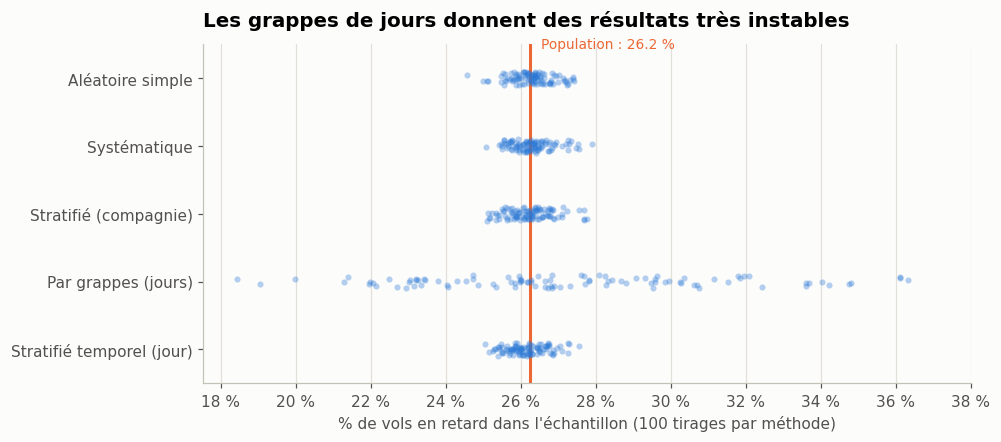

,mean,std,min,max
méthode,,,,
Stratifié temporel (jour),26.15,0.52,25.04,27.56
Systématique,26.29,0.53,25.08,27.89
Aléatoire simple,26.29,0.55,24.58,27.41
Stratifié (compagnie),26.23,0.60,25.11,27.77
Par grappes (jours),27.27,3.92,18.44,36.33


In [15]:
stabilite = stabilite_des_methodes(vols, nb_tirages=100)
vraie_valeur = vols_partis(vols)["DepDel15"].mean() * 100

fig, axe = plt.subplots(figsize=(9, 4))
ordre = list(METHODES)
sns.stripplot(data=stabilite, y="méthode", x="% en retard", order=ordre, color=BLEU, alpha=0.35, size=4, ax=axe)
axe.axvline(vraie_valeur, color=ORANGE, linewidth=2)
axe.text(vraie_valeur + 0.3, -0.45, f"Population : {vraie_valeur:.1f} %", color=ORANGE, fontsize=9)
axe.set_title("Les grappes de jours donnent des résultats très instables")
axe.set_xlabel("% de vols en retard dans l'échantillon (100 tirages par méthode)")
axe.set_ylabel("")
axe.set_xticks(range(18, 39, 2))
format_pourcentage(axe, "x")
axe.grid(axis="x", visible=True); axe.grid(axis="y", visible=False)
enregistrer_figure("09_stabilite_echantillonnage")
plt.show()

stabilite.groupby("méthode")["% en retard"].agg(["mean", "std", "min", "max"]).round(2).sort_values("std")

**Cette visualisation montre que :**
- les méthodes aléatoire simple, systématique et stratifiées restent toujours **proches de la vraie valeur**
  (écart-type ≈ 0,5 à 0,7 point) ;
- l'échantillonnage **par grappes** varie énormément (de ≈ 18 % à ≈ 36 % selon les jours tirés) :
  les retards dépendent beaucoup du jour (orages, jours chargés), donc 6 jours ne suffisent pas à représenter l'été.

**Choix retenu :** l'échantillon **stratifié par jour** (écart-type parmi les plus faibles, 0,52 point, et chacun des 61 jours représenté).
Il sera utilisé pour les nuages de points et dans le dashboard. Tous les **pourcentages et moyennes**
restent calculés sur la **population complète** (54 461 vols).

In [16]:
echantillon = echantillon_stratifie_par_jour(vols)
print("Taille de l'échantillon retenu :", len(echantillon))

Taille de l'échantillon retenu : 4994


## 10. Analyse univariée

*Étape 1 de l'histoire — « Que se passe-t-il ? »*

On étudie une variable à la fois, en se limitant aux variables utiles à la problématique.

### 10.1 Que deviennent les vols ? (statut)

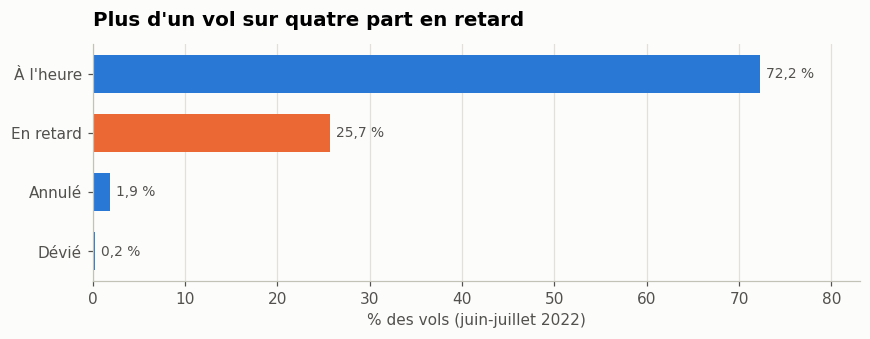

In [17]:
parts_statut = vols["statut"].value_counts(normalize=True) * 100
barres_horizontales(parts_statut, "Plus d'un vol sur quatre part en retard",
                    "% des vols (juin-juillet 2022)", a_mettre_en_avant=["En retard"])
enregistrer_figure("10_statut_des_vols")
plt.show()

**Cette visualisation montre que** 72 % des vols partent à l'heure, mais **26 % partent avec plus de
15 minutes de retard**, soit plus d'un vol sur quatre. Les annulations (1,9 %) et les déviations (0,2 %) sont rares.
→ Le retard est un phénomène **fréquent**, pas exceptionnel.

### 10.2 Distribution du retard au départ

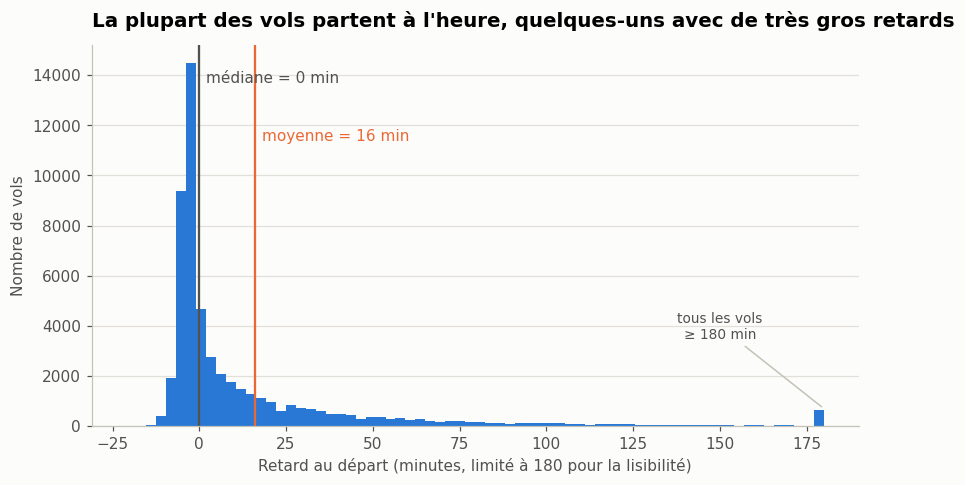

Vols partis en avance : 49.1 %
Vols avec plus d'1 h de retard : 8.4 %


In [18]:
partis = vols_partis(vols)
fig, axe = plt.subplots()
axe.hist(partis["DepDelay"].clip(-30, 180), bins=70, color=BLEU)
mediane, moyenne = partis["DepDelay"].median(), partis["DepDelay"].mean()
axe.axvline(mediane, color=ENCRE_SECONDAIRE, linewidth=1.5)
axe.axvline(moyenne, color=ORANGE, linewidth=1.5)
axe.text(mediane + 2, axe.get_ylim()[1] * 0.9, f"médiane = {mediane:.0f} min", color=ENCRE_SECONDAIRE)
axe.text(moyenne + 2, axe.get_ylim()[1] * 0.75, f"moyenne = {moyenne:.0f} min", color=ORANGE)
axe.annotate("tous les vols\n≥ 180 min", (180, 700), xytext=(150, 3500), color=ENCRE_SECONDAIRE,
             fontsize=9, ha="center", arrowprops=dict(arrowstyle="-", color=GRIS))
axe.set_title("La plupart des vols partent à l'heure, quelques-uns avec de très gros retards")
axe.set_xlabel("Retard au départ (minutes, limité à 180 pour la lisibilité)")
axe.set_ylabel("Nombre de vols")
enregistrer_figure("10_distribution_retard")
plt.show()

print(f"Vols partis en avance : {(partis['DepDelay'] < 0).mean() * 100:.1f} %")
print(f"Vols avec plus d'1 h de retard : {(partis['DepDelay'] > 60).mean() * 100:.1f} %")

**Cette visualisation montre que** la distribution est **très asymétrique** (« longue traîne » à droite) :
- près de la moitié des vols (49 %) partent **en avance** ;
- le pic est autour de 0 min ;
- mais 8,4 % des vols ont **plus d'une heure** de retard, ce qui tire la moyenne (16 min) bien au-dessus de la médiane (0 min).

→ C'est pour cela qu'on utilise le **% de vols en retard** plutôt que la moyenne.

### 10.3 À quelle heure partent les vols ?

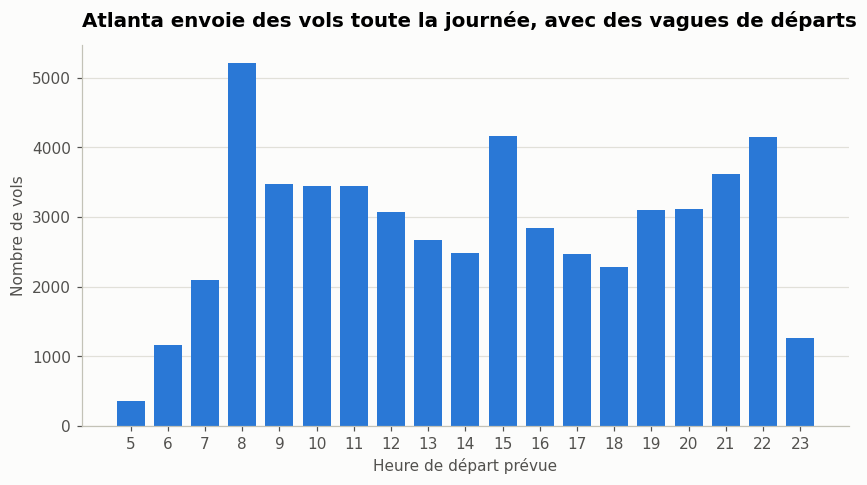

In [19]:
vols_par_heure = vols["heure_depart_prevue"].value_counts().sort_index()
fig, axe = plt.subplots()
axe.bar(vols_par_heure.index, vols_par_heure.values, color=BLEU, width=0.75)
axe.set_title("Atlanta envoie des vols toute la journée, avec des vagues de départs")
axe.set_xlabel("Heure de départ prévue")
axe.set_ylabel("Nombre de vols")
axe.set_xticks(range(5, 24))
enregistrer_figure("10_vols_par_heure")
plt.show()

**Cette visualisation montre que** les départs s'étalent de 5 h à 23 h, avec des **vagues** (8 h, 15 h, 21-22 h).
C'est le fonctionnement en « hub » : Delta regroupe ses départs en vagues pour faciliter les correspondances.
Il y a du trafic à toutes les heures, donc on pourra comparer le retard heure par heure.

### 10.4 Quelles compagnies opèrent à Atlanta ?

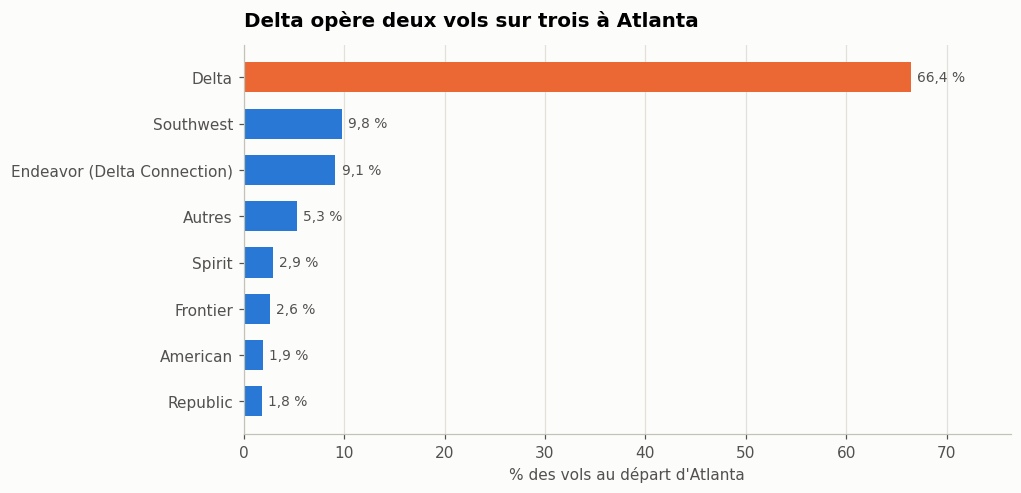

In [20]:
parts_compagnies = vols["compagnie"].value_counts(normalize=True) * 100
barres_horizontales(parts_compagnies, "Delta opère deux vols sur trois à Atlanta",
                    "% des vols au départ d'Atlanta", a_mettre_en_avant=["Delta"])
enregistrer_figure("10_compagnies")
plt.show()

**Cette visualisation montre que** Delta domine (66 % des vols), car Atlanta est sa base principale ;
avec Endeavor (filiale régionale de Delta), le groupe Delta dépasse 75 %. Southwest arrive loin derrière (10 %).

→ **Conséquence pour l'analyse :** le taux de retard global d'Atlanta dépend surtout de Delta. En comparant les
compagnies, il faudra se rappeler que les petites compagnies ont beaucoup moins de vols.

## 11. Analyse bivariée

*Étapes 2 et 3 de l'histoire — « Quand, où, chez qui ? » et « Quels facteurs sont associés au retard ? »*

### 11.1 Le retard selon l'heure de départ (temporelle × numérique)

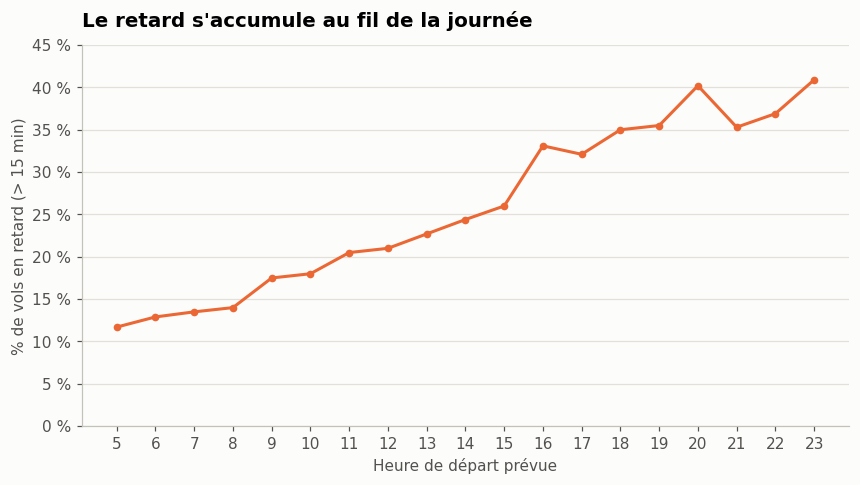

heure_depart_prevue,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
nb_vols,351.0,1137.0,2027.0,5138.0,3421.0,3404.0,3396.0,3009.0,2633.0,2443.0,4094.0,2783.0,2416.0,2228.0,3033.0,3066.0,3564.0,4081.0,1228.0
pct_retard,11.7,12.9,13.5,14.0,17.5,18.0,20.5,21.0,22.7,24.4,26.0,33.1,32.1,35.0,35.5,40.2,35.3,36.9,40.9
retard_median_min,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-2.0,-1.0,-1.0,0.0,0.0,1.0,0.0,3.0,3.0,6.0,2.0,4.0,7.0


In [21]:
retard_par_heure = taux_de_retard_par(vols, "heure_depart_prevue")
axe = ligne_temporelle(retard_par_heure["pct_retard"], "Le retard s'accumule au fil de la journée",
                       "Heure de départ prévue", "% de vols en retard (> 15 min)", couleur=ORANGE)
format_pourcentage(axe)
axe.set_xticks(range(5, 24))
axe.set_ylim(0, 45)
enregistrer_figure("11_retard_par_heure")
plt.show()
retard_par_heure.T

**Cette visualisation montre que** le % de vols en retard **augmente presque régulièrement** au fil de la journée :
**≈ 12-13 % le matin** (5-7 h) contre **≈ 35-40 % le soir** (18-23 h). Un vol du soir a environ **3 fois plus
de risque** d'être en retard qu'un vol du matin.

**Interprétation prudente :** le matin, les avions sortent d'une nuit au sol et partent à l'heure. Ensuite, les petits
retards s'additionnent d'un vol à l'autre. S'y ajoutent probablement les **orages d'été de l'après-midi** (non présents
dans les données). C'est la première trace de l'**effet domino**, vérifiée directement en 11.6.

### 11.2 Le retard selon la compagnie (catégorielle × numérique)

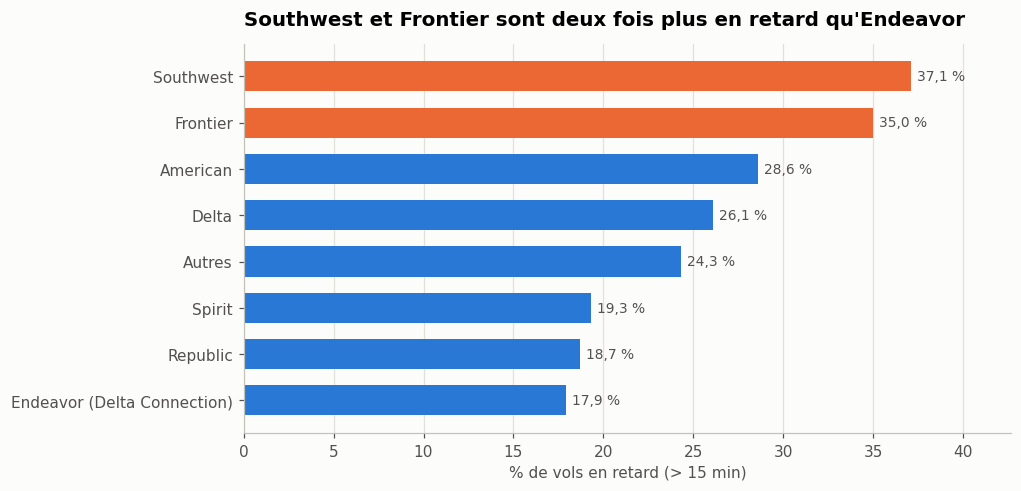

,nb_vols,pct_retard,retard_median_min
compagnie,,,
Endeavor (Delta Connection),4929,17.9,-3.0
Republic,950,18.7,-4.0
Spirit,1574,19.3,-1.0
Autres,2824,24.3,-2.0
Delta,35473,26.1,0.0
American,1006,28.6,0.0
Frontier,1407,35.0,2.0
Southwest,5289,37.1,6.0


In [22]:
retard_par_compagnie = taux_de_retard_par(vols, "compagnie")
barres_horizontales(retard_par_compagnie["pct_retard"], "Southwest et Frontier sont deux fois plus en retard qu'Endeavor",
                    "% de vols en retard (> 15 min)", a_mettre_en_avant=["Southwest", "Frontier"])
enregistrer_figure("11_retard_par_compagnie")
plt.show()
retard_par_compagnie.sort_values("pct_retard")

**Cette visualisation montre que** les écarts entre compagnies sont **importants** :
Endeavor (17,9 %), Republic et Spirit (≈ 19 %) sont les plus ponctuelles ; **Southwest (37,1 %) et Frontier (35 %)**
sont les plus en retard. Delta (26,1 %) est dans la moyenne… logiquement, puisqu'elle **fait** la moyenne (66 % des vols).

**Prudence :** ces compagnies n'ont pas les mêmes horaires ni les mêmes destinations. Une partie de l'écart
peut venir de là (voir l'analyse multivariée 12.3).

### 11.3 Le retard jour par jour sur l'été (temporelle × numérique)

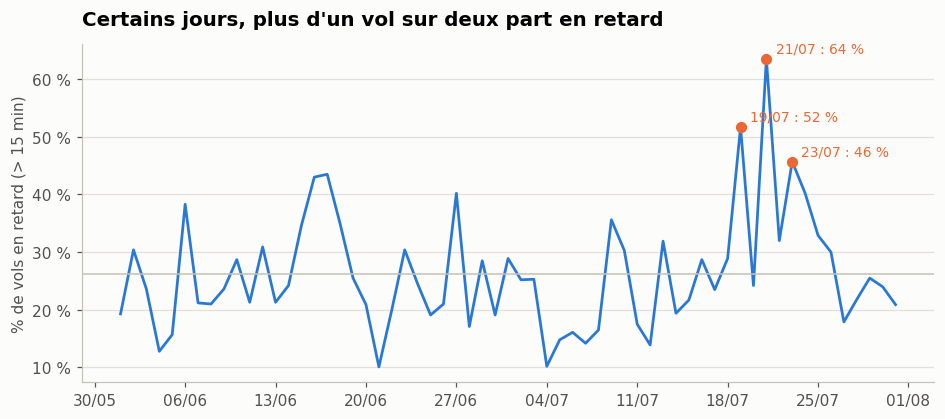

Jour le plus calme : 10.1 %  |  jour le pire : 63.5 %  |  écart-type : 10.1 points


In [23]:
retard_par_jour = taux_de_retard_par(vols, "FlightDate")["pct_retard"]
fig, axe = plt.subplots(figsize=(10, 4))
axe.plot(retard_par_jour.index, retard_par_jour.values, color=BLEU, linewidth=1.8)
pires_jours = retard_par_jour.nlargest(3)
axe.scatter(pires_jours.index, pires_jours.values, color=ORANGE, s=40, zorder=3)
for date, valeur in pires_jours.items():
    axe.annotate(f"{date:%d/%m} : {valeur:.0f} %", (date, valeur), textcoords="offset points", xytext=(6, 4), color=ORANGE, fontsize=9)
axe.axhline(retard_par_jour.mean(), color=GRIS, linewidth=1)
axe.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
axe.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
axe.set_title("Certains jours, plus d'un vol sur deux part en retard")
axe.set_ylabel("% de vols en retard (> 15 min)")
format_pourcentage(axe)
enregistrer_figure("11_retard_par_jour")
plt.show()
print(f"Jour le plus calme : {retard_par_jour.min():.1f} %  |  jour le pire : {retard_par_jour.max():.1f} %  |  écart-type : {retard_par_jour.std():.1f} points")

**Cette visualisation montre que** le retard **varie énormément d'un jour à l'autre** : de 10 % (21 juin, 4 juillet)
à **63,5 % le 21 juillet**. 7 jours dépassent 40 %. Ces pics isolés ressemblent à des événements ponctuels
(orages, problèmes d'équipage…), mais le dataset ne contient pas de données météo : on ne peut pas le vérifier ici.

C'est aussi ce qui explique l'instabilité de l'échantillonnage par grappes (section 9).

### 11.4 Le statut selon le jour de la semaine (catégorielle × catégorielle)

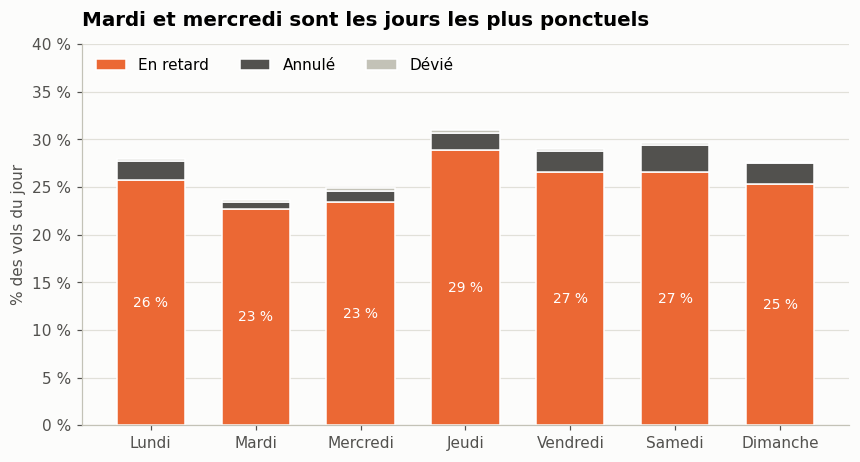

statut,En retard,Annulé,Dévié
jour_semaine,,,
Lundi,25.8,2.0,0.2
Mardi,22.7,0.7,0.2
Mercredi,23.5,1.2,0.3
Jeudi,28.9,1.8,0.3
Vendredi,26.6,2.2,0.3
Samedi,26.6,2.8,0.2
Dimanche,25.3,2.2,0.1


In [24]:
ordre_jours = ["Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi", "Samedi", "Dimanche"]
statut_par_jour = pd.crosstab(vols["jour_semaine"], vols["statut"], normalize="index").mul(100).loc[ordre_jours]
statut_par_jour = statut_par_jour[["En retard", "Annulé", "Dévié"]]

fig, axe = plt.subplots()
bas = pd.Series(0.0, index=ordre_jours)
for statut, couleur in [("En retard", ORANGE), ("Annulé", ENCRE_SECONDAIRE), ("Dévié", GRIS)]:
    axe.bar(ordre_jours, statut_par_jour[statut], bottom=bas, color=couleur, label=statut, width=0.65, edgecolor="white", linewidth=1)
    bas += statut_par_jour[statut]
axe.bar_label(axe.containers[0], fmt="%.0f %%", label_type="center", color="white", fontsize=9)
axe.set_title("Mardi et mercredi sont les jours les plus ponctuels")
axe.set_ylabel("% des vols du jour")
format_pourcentage(axe)
axe.legend(loc="upper left", ncols=3)
axe.set_ylim(0, 40)
enregistrer_figure("11_statut_par_jour_semaine")
plt.show()
statut_par_jour.round(1)

**Cette visualisation montre que** **mardi (23 %) et mercredi (24 %)** sont les jours les plus ponctuels,
**jeudi (29 %)** le moins ponctuel. Les annulations sont plus fréquentes le week-end (samedi 2,8 %).
L'écart entre jours (≈ 6 points) est **plus faible** que l'écart entre heures (≈ 28 points) :
l'heure compte plus que le jour.

### 11.5 Le retard se rattrape-t-il en vol ? (numérique × numérique)

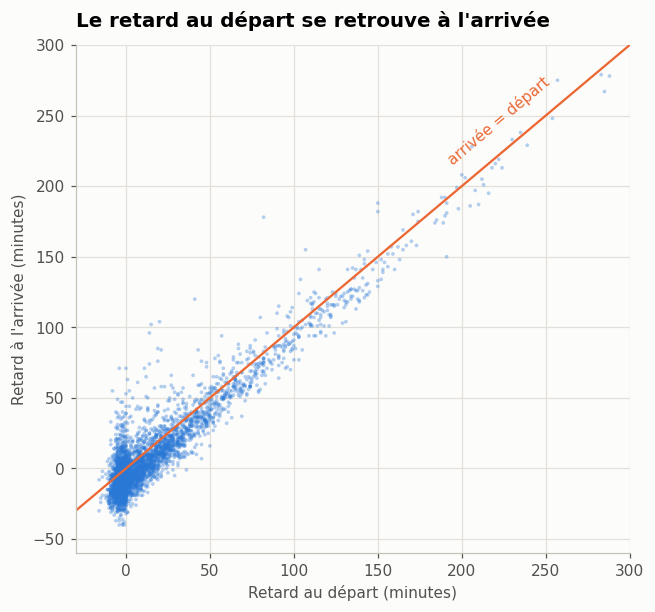

Corrélation retard départ / arrivée : 0.98
Minutes rattrapées en vol (médiane, tous vols) : 7 min
Vols partis en retard qui arrivent quand même à l'heure : 20 %


In [25]:
fig, axe = plt.subplots(figsize=(6.5, 6))
axe.scatter(echantillon["DepDelay"], echantillon["ArrDelay"], s=6, color=BLEU, alpha=0.35, edgecolors="none")
axe.plot([-30, 300], [-30, 300], color=ORANGE, linewidth=1.5)
axe.text(190, 215, "arrivée = départ", color=ORANGE, rotation=40)
axe.set_xlim(-30, 300); axe.set_ylim(-60, 300)
axe.set_title("Le retard au départ se retrouve à l'arrivée")
axe.set_xlabel("Retard au départ (minutes)")
axe.set_ylabel("Retard à l'arrivée (minutes)")
axe.grid(axis="x", visible=True)
enregistrer_figure("11_depart_vs_arrivee")
plt.show()

correlation = partis[["DepDelay", "ArrDelay"]].corr().iloc[0, 1]
en_retard = partis[partis["DepDel15"] == 1]
print(f"Corrélation retard départ / arrivée : {correlation:.2f}")
print(f"Minutes rattrapées en vol (médiane, tous vols) : {partis['minutes_rattrapees'].median():.0f} min")
print(f"Vols partis en retard qui arrivent quand même à l'heure : {(en_retard['ArrDel15'] == 0).mean() * 100:.0f} %")

*(Nuage de points dessiné avec l'échantillon stratifié de 5 000 vols pour rester lisible ; les chiffres sont calculés sur tous les vols.)*

**Cette visualisation montre que** les points suivent presque parfaitement la diagonale : **corrélation = 0,98**.
Un vol parti en retard arrive en retard. Les points sont un peu **sous** la diagonale : les avions regagnent
en moyenne **≈ 7 minutes** en vol, mais seulement **20 %** des vols partis en retard arrivent finalement à l'heure.

→ **Le retard au départ est décisif** : c'est bien lui qu'il faut comprendre. (Ici la relation est logique et non
une coïncidence : le retard à l'arrivée est en grande partie le retard au départ.)

### 11.6 L'effet domino : le retard du vol précédent du même avion

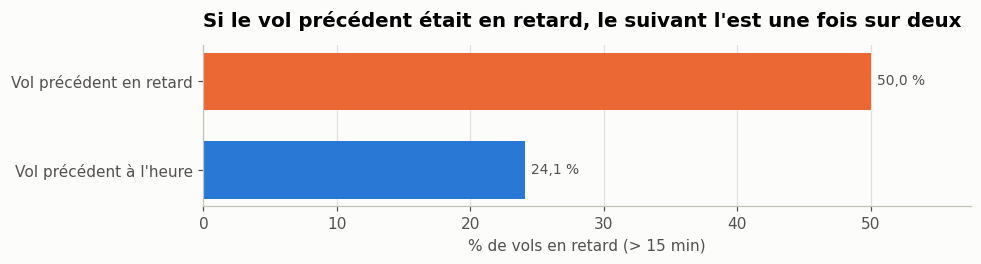

,nb_vols,pct_retard,retard_median_min
vol_precedent_en_retard,,,
Vol précédent à l'heure,17721,24.1,-1.0
Vol précédent en retard,4306,50.0,14.5


In [26]:
domino = effet_domino(vols)
barres_horizontales(domino["pct_retard"], "Si le vol précédent était en retard, le suivant l'est une fois sur deux",
                    "% de vols en retard (> 15 min)", a_mettre_en_avant=["Vol précédent en retard"])
enregistrer_figure("11_effet_domino")
plt.show()
domino

**Comment c'est calculé :** un avion (identifié par son immatriculation `Tail_Number`) part souvent plusieurs fois par jour
d'Atlanta : il part, fait un aller-retour, et repart. Pour chaque départ, on regarde si **son départ précédent, le même jour**,
était en retard.

**Cette visualisation montre que :**
- si le vol précédent du même avion était **à l'heure**, le vol suivant est en retard dans **24 %** des cas ;
- s'il était **en retard**, le vol suivant est en retard dans **50 %** des cas, soit **2 fois plus**.

C'est la mesure directe de l'**effet domino**. Le BTS reconnaît d'ailleurs officiellement cette cause de retard
(*« Aircraft Arriving Late »*).
**Prudence :** c'est une association, pas une preuve de causalité à elle seule : les deux vols partagent aussi la même
journée (météo, affluence). La section 12.2 vérifie que l'effet résiste à l'heure de départ.

### 11.7 La distance joue-t-elle un rôle ? (numérique × numérique)

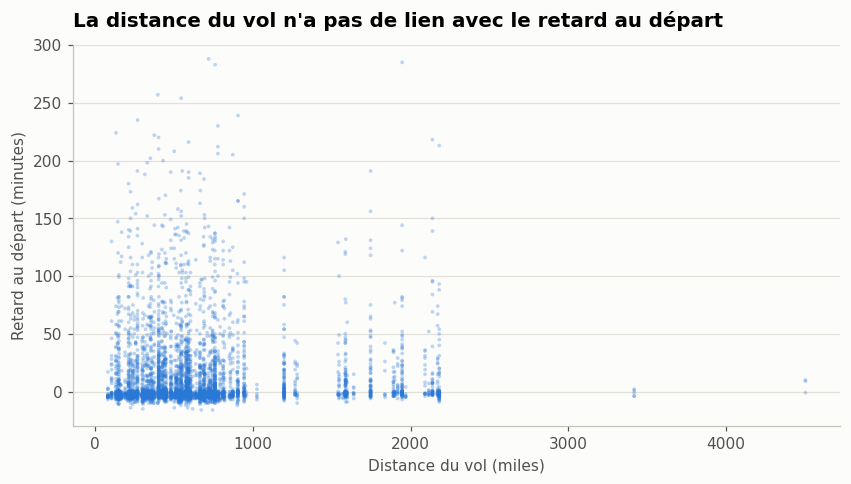

Corrélation distance / retard au départ : 0.01


In [27]:
fig, axe = plt.subplots()
axe.scatter(echantillon["Distance"], echantillon["DepDelay"], s=6, color=BLEU, alpha=0.3, edgecolors="none")
axe.set_ylim(-30, 300)
axe.set_title("La distance du vol n'a pas de lien avec le retard au départ")
axe.set_xlabel("Distance du vol (miles)")
axe.set_ylabel("Retard au départ (minutes)")
enregistrer_figure("11_distance_vs_retard")
plt.show()
print(f"Corrélation distance / retard au départ : {partis[['Distance', 'DepDelay']].corr().iloc[0, 1]:.2f}")

**Cette visualisation montre qu'**il n'y a **aucune relation** (corrélation ≈ 0,01) : un vol long n'est ni plus
ni moins en retard au départ qu'un vol court. C'est logique : le retard au départ se crée **au sol, avant le décollage**,
pas pendant le vol. Ce résultat « négatif » est utile : il écarte une piste.

### 11.8 Corrélations entre les variables numériques clés

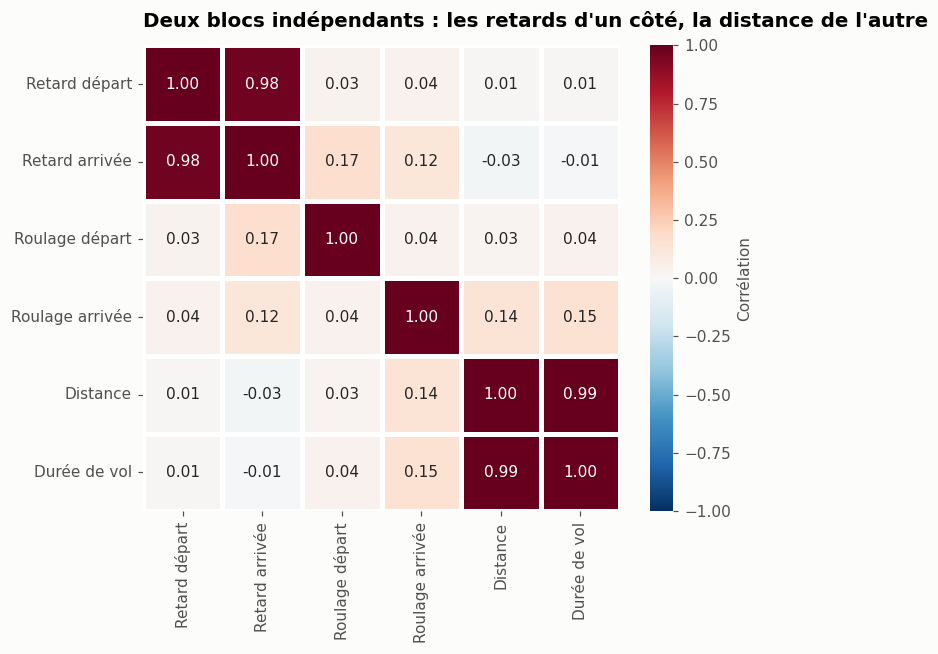

In [28]:
correlations = partis[VARIABLES_NUMERIQUES_CLES].corr()
noms_lisibles = {"DepDelay": "Retard départ", "ArrDelay": "Retard arrivée", "TaxiOut": "Roulage départ",
                 "TaxiIn": "Roulage arrivée", "Distance": "Distance", "AirTime": "Durée de vol"}
correlations = correlations.rename(index=noms_lisibles, columns=noms_lisibles)

fig, axe = plt.subplots(figsize=(7, 5.5))
sns.heatmap(correlations, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, center=0,
            linewidths=2, linecolor="white", cbar_kws={"label": "Corrélation"}, ax=axe)
axe.set_title("Deux blocs indépendants : les retards d'un côté, la distance de l'autre")
enregistrer_figure("11_correlations")
plt.show()

*(On ne met que 6 variables choisies, et pas les 40 colonnes numériques : beaucoup sont des codes ou des doublons.)*

**Cette visualisation montre** deux blocs :
- **retard départ ↔ retard arrivée** : 0,98 (le même retard mesuré deux fois) ;
- **distance ↔ durée de vol** : 0,99 (évident : plus c'est loin, plus c'est long).

Entre les deux blocs, les corrélations sont proches de 0. Le **temps de roulage au départ** (`TaxiOut`)
est un peu lié au retard à l'arrivée (0,17) : un embouteillage sur les pistes ajoute du retard.
Rappel : **corrélation ≠ causalité**.

## 12. Analyse multivariée

*Étape 4 de l'histoire — « Quels profils de vols sont les plus à risque ? »*

### 12.1 Jour de la semaine × heure de départ

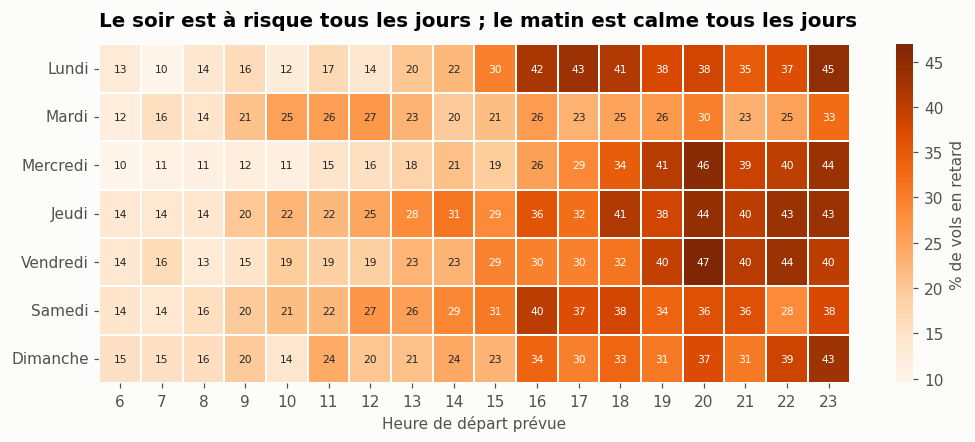

In [29]:
carte_jour_heure = tableau_croise_retard(vols, "jour_semaine", "heure_depart_prevue").loc[ordre_jours, 6:23]
fig, axe = plt.subplots(figsize=(11, 4))
sns.heatmap(carte_jour_heure, cmap="Oranges", annot=True, fmt=".0f", annot_kws={"size": 7},
            linewidths=1, linecolor="white", cbar_kws={"label": "% de vols en retard"}, ax=axe)
axe.grid(False)
axe.set_title("Le soir est à risque tous les jours ; le matin est calme tous les jours")
axe.set_xlabel("Heure de départ prévue")
axe.set_ylabel("")
enregistrer_figure("12_heatmap_jour_heure")
plt.show()

**Cette visualisation montre que** l'effet de l'heure est **présent tous les jours de la semaine** : la carte passe
du clair (matin) au foncé (soir) sur chaque ligne. Les cases les plus foncées sont les soirées (après 18 h) du lundi, mercredi, jeudi et vendredi
(≈ 40 à 47 %). Le mardi reste le jour le plus clair, même le soir.
→ **Profil le plus à risque : un vol en soirée en fin de semaine. Le plus sûr : un vol tôt le matin.**

### 12.2 L'effet domino résiste-t-il à l'heure de départ ? (3 variables)

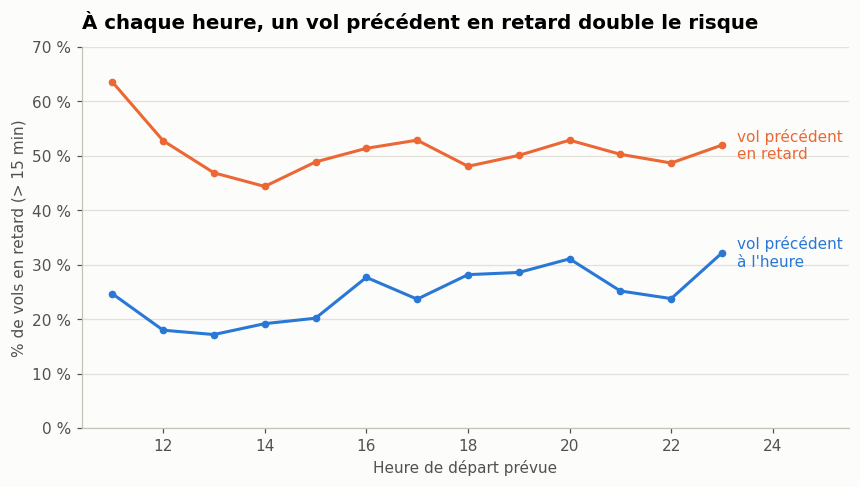

In [30]:
partis_avec_precedent = partis[partis["vol_precedent_en_retard"].notna()]
domino_par_heure = tableau_croise_retard(partis_avec_precedent, "heure_depart_prevue", "vol_precedent_en_retard")
nb_vols_par_heure = partis_avec_precedent["heure_depart_prevue"].value_counts()
domino_par_heure = domino_par_heure[nb_vols_par_heure.reindex(domino_par_heure.index) >= 200]  # heures avec assez de vols

fig, axe = plt.subplots()
axe.plot(domino_par_heure.index, domino_par_heure[1.0], color=ORANGE, linewidth=2, marker="o", markersize=4)
axe.plot(domino_par_heure.index, domino_par_heure[0.0], color=BLEU, linewidth=2, marker="o", markersize=4)
derniere_heure = domino_par_heure.index.max()
axe.text(derniere_heure + 0.3, domino_par_heure.loc[derniere_heure, 1.0], "vol précédent\nen retard", color=ORANGE, va="center")
axe.text(derniere_heure + 0.3, domino_par_heure.loc[derniere_heure, 0.0], "vol précédent\nà l'heure", color=BLEU, va="center")
axe.set_xlim(right=derniere_heure + 2.5)
axe.set_ylim(0, 70)
axe.set_title("À chaque heure, un vol précédent en retard double le risque")
axe.set_xlabel("Heure de départ prévue")
axe.set_ylabel("% de vols en retard (> 15 min)")
format_pourcentage(axe)
enregistrer_figure("12_domino_par_heure")
plt.show()

*(On ne garde que les heures avec au moins 200 vols, pour que les pourcentages soient fiables.)*

**Cette visualisation montre que** l'écart entre les deux courbes existe **à toutes les heures** : à heure égale,
un avion dont le vol précédent était en retard a **environ 2 fois plus** de risque de repartir en retard
(≈ 45-55 % contre ≈ 20-30 %).
→ L'effet domino **n'est pas seulement un effet de l'heure** : il s'ajoute à lui. C'est le résultat central du projet.

### 12.3 Compagnie × heure : les compagnies suivent-elles toutes la même courbe ?

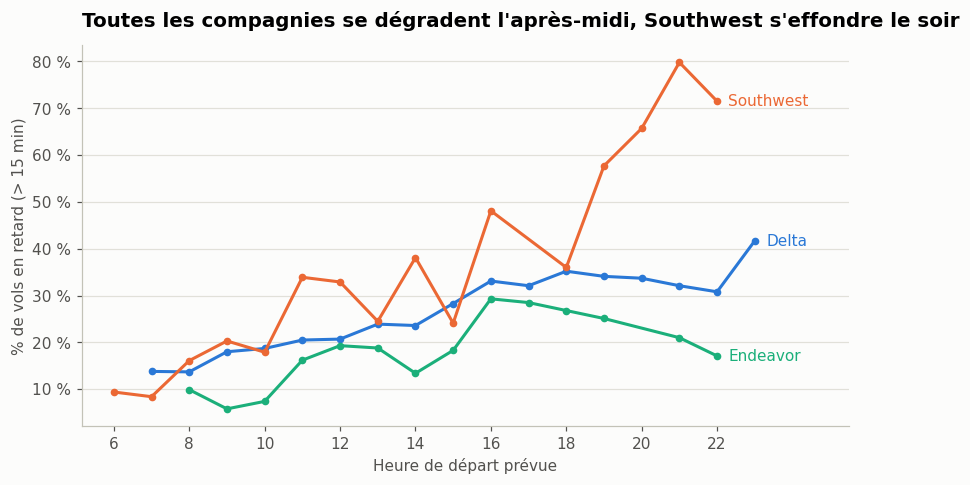

In [31]:
trois_compagnies = ["Delta", "Southwest", "Endeavor (Delta Connection)"]
compagnie_heure = tableau_croise_retard(vols[vols["compagnie"].isin(trois_compagnies)], "heure_depart_prevue", "compagnie")
vols_compagnie_heure = vols_partis(vols).groupby(["heure_depart_prevue", "compagnie"]).size().unstack()
compagnie_heure = compagnie_heure.where(vols_compagnie_heure[trois_compagnies] >= 100)  # on masque les cases trop petites

fig, axe = plt.subplots()
for compagnie, couleur in zip(trois_compagnies, [BLEU, ORANGE, VERT_EAU]):
    serie = compagnie_heure[compagnie].dropna()
    axe.plot(serie.index, serie.values, color=couleur, linewidth=2, marker="o", markersize=4)
    axe.text(serie.index[-1] + 0.3, serie.values[-1], compagnie.split(" (")[0], color=couleur, va="center")
axe.set_xlim(right=25.5)
axe.set_xticks(range(6, 24, 2))
axe.set_title("Toutes les compagnies se dégradent l'après-midi, Southwest s'effondre le soir")
axe.set_xlabel("Heure de départ prévue")
axe.set_ylabel("% de vols en retard (> 15 min)")
format_pourcentage(axe)
enregistrer_figure("12_compagnie_heure")
plt.show()

*(Cases avec moins de 100 vols masquées.)*

**Cette visualisation montre que** les trois principales compagnies **suivent la même tendance** jusqu'à 16 h
(le retard monte au fil de la journée) : l'effet de l'heure est général.
Ensuite, elles se séparent : **Southwest s'effondre en soirée** (≈ 58 % à 19 h, ≈ 80 % à 21 h), alors que Delta reste
autour de 30-35 % et qu'Endeavor redescend vers 17-20 %. Endeavor, filiale régionale de Delta, est la plus ponctuelle
à presque toutes les heures.

→ Le mauvais score global de Southwest vient surtout de **ses vols du soir**. Hypothèse : son réseau est fait de longues
chaînes de vols pour chaque avion, ce qui accumule les retards (effet domino) jusqu'au soir.

### 12.4 Destinations : distance, volume et retard (graphique interactif)

In [32]:
retard_par_destination = taux_de_retard_par(vols, "Dest")
retard_par_destination["distance_miles"] = vols.groupby("Dest")["Distance"].first()
destinations_principales = retard_par_destination[retard_par_destination["nb_vols"] >= 300].reset_index()

figure = px.scatter(
    destinations_principales, x="distance_miles", y="pct_retard", size="nb_vols", text="Dest",
    hover_data={"nb_vols": True, "retard_median_min": True},
    labels={"distance_miles": "Distance depuis Atlanta (miles)", "pct_retard": "% de vols en retard",
            "nb_vols": "Nombre de vols", "retard_median_min": "Retard médian (min)"},
    title="Les vols vers la Floride et New York sont les plus souvent en retard",
)
figure.update_traces(marker=dict(color=BLEU, opacity=0.6, line=dict(width=1, color="white")),
                     textposition="top center", textfont_size=9)
figure.update_layout(**PLOTLY_LAYOUT, height=550)
figure.show()
destinations_principales.sort_values("pct_retard").iloc[[0, 1, 2, -3, -2, -1]]

,Dest,nb_vols,pct_retard,retard_median_min,distance_miles
71,TRI,315,14.0,-4.0,227.0
0,AGS,346,15.9,-3.0,143.0
23,GSO,395,17.0,-2.0,306.0
70,TPA,980,35.2,3.0,406.0
33,JFK,639,36.8,6.0,760.0
40,MCO,1345,38.0,5.0,404.0


*(74 destinations avec au moins 300 vols. Survoler une bulle affiche le détail ; la taille = le nombre de vols.)*

**Cette visualisation montre que :**
- la distance ne sépare pas les destinations (confirmation de 11.7) ;
- les destinations les plus en retard sont **Orlando (MCO, 38 %), New York JFK (37 %), Tampa (35 %), Raleigh (35 %) et Fort Lauderdale (34,5 %)** :
  la Floride revient plusieurs fois ;
- les plus ponctuelles sont de **petits aéroports régionaux proches** (Tri-Cities TRI 14 %, Augusta AGS 16 %).

**Hypothèse (non vérifiable ici) :** les orages d'été en Floride et la congestion de l'espace aérien new-yorkais.

## 13. Insights principaux

*Étape 5 de l'histoire — « Que retenir ? »*

**Insight 1 — Le retard est fréquent.** 26 % des vols partent avec plus de 15 min de retard. La médiane est de 0 min,
mais 8 % des vols dépassent 1 h de retard.

**Insight 2 — Le retard grandit au fil de la journée.** De ≈ 12 % à 6 h à ≈ 40 % à 20 h : un vol du soir a environ
3 fois plus de risque d'être en retard qu'un vol du matin, et ce, **tous les jours de la semaine**.

**Insight 3 — L'effet domino est mesurable.** Quand le vol précédent du même avion était en retard, le suivant l'est
**une fois sur deux** (50 % contre 24 %), et cet écart existe **à chaque heure** de la journée.

**Insight 4 — Le retard se joue au départ.** Il se retrouve presque entièrement à l'arrivée (corrélation 0,98) ;
seulement 20 % des vols partis en retard arrivent à l'heure. La distance du vol n'a aucun lien avec le retard.

**Insight 5 — Les compagnies ne se valent pas.** Southwest (37 %) et Frontier (35 %) sont deux fois plus souvent en retard
qu'Endeavor (18 %) ; pour Southwest, l'écart vient surtout des vols du soir (jusqu'à 80 % en retard à 21 h).

**Insight 6 — Certains jours font exploser les retards.** Le pourcentage varie de 10 % à 63 % selon le jour :
des événements ponctuels (probablement météo) pèsent lourd.

## 14. Conclusion

**Réponse à la problématique :** à Atlanta pendant l'été 2022, les vols prennent surtout du retard **en fin de journée**,
parce que les retards **se transmettent d'un vol à l'autre du même avion** (effet domino). Ce mécanisme touche toutes
les compagnies, mais certaines (Southwest, Frontier) sont nettement plus exposées, et certains jours exceptionnels
aggravent fortement la situation.

**Recommandation opérationnelle possible :** protéger les **premières rotations** de la journée (marges de temps au sol,
avions de réserve) serait le levier le plus efficace, puisque chaque retard évité le matin en évite d'autres l'après-midi.

### Limites
- **Périmètre :** un seul aéroport (Atlanta) et deux mois d'été. Les résultats ne se généralisent pas automatiquement à
  l'hiver ou à d'autres aéroports.
- **Variables absentes :** pas de météo, pas de causes de retard détaillées dans ce fichier (elles existent dans les
  fichiers bruts mensuels du dataset), pas de nombre de passagers.
- **Effet domino partiel :** on ne voit que les départs d'Atlanta. Le vol retour vers Atlanta (entre deux départs)
  n'est pas dans notre périmètre, donc la chaîne complète n'est pas observée.
- **Domination de Delta :** 66 % des vols. Les petites compagnies ont peu de vols, leurs pourcentages sont moins fiables.
- **Causalité :** toutes les relations sont des **associations**. Les deux vols d'un même avion partagent la même journée
  (météo, affluence) : l'effet domino est très probable (et reconnu par le BTS), mais nos données seules ne le prouvent pas.
- **Qualité :** données officielles fiables, mais déclaratives (les compagnies déclarent leurs horaires).

**Avec plus de données**, on ajouterait la météo horaire d'Atlanta, les causes officielles de retard, et une année complète
pour comparer les saisons.